In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [3]:
df = pd.read_csv('..\\..\\data\\age_hf\\lat_long_age_q_FA.txt', sep='\t', header=None, 
                 names=['lat', 'lon', 'age', 'q', 'FA'])
print(df.head())

     lat     lon       age      q         FA
0  49.62 -129.98  0.816961  366.0   2.029732
1  44.68 -125.29  9.119624   79.0 -66.546684
2  44.66 -125.27  9.119624   81.0 -66.546684
3  44.66 -125.27  9.119624   93.0 -66.546684
4  44.66 -125.26  9.119624   77.0 -66.546684


now for pars-scl, we get depth from formula 21 and heat flow from formula 23... and for stein x2 we get depth and heat flow from pg 126

In [4]:
ihfc_qt = []
sqrt_age = []
ps_qt = []
dt_ps = []
stein_qt = []
dt_stein = []

# ihfc
for q in df['q']:
    ihfc_qt.append(q*0.0238846)  # mW/m^2 --> μcal/cm^2*s

# pars-scl
for a in df['age']:
    sqrt_age.append(a**(0.5))
    dt_ps.append(2500 + 350*(a**(0.5)))
    ps_qt.append(11.3/a**(0.5))

# stein x2
for a in df['age']:
    dt_stein.append(2600 + 365*(a**0.5))
    stein_qt.append((510/a**(0.5))*0.0239)  # mW/m^2 --> μcal/cm^2*s

print(f'pars-scl depth: {dt_ps[0:11]}\nstein depth: {dt_stein[0:11]}')
# print(f'sqrt(age): {sqrt_age[:2]}')
# print(f'ihfc heat flow: {ihfc_qt[:2]}, pars-scl heat flow: {ps_qt[:2]}, stein heat flow: {stein_qt[:2]}')

pars-scl depth: [2816.350676741808, 3556.955037951, 3556.955037951, 3556.955037951, 3556.955037951, 3556.955037951, 3547.976642988764, 3556.955037951, 3556.955037951, 3556.955037951, 3559.058874779868]
stein depth: [2929.9085628878856, 3702.2531110060427, 3702.2531110060427, 3702.2531110060427, 3702.2531110060427, 3702.2531110060427, 3692.889927688283, 3702.2531110060427, 3702.2531110060427, 3702.2531110060427, 3704.4471122704335]


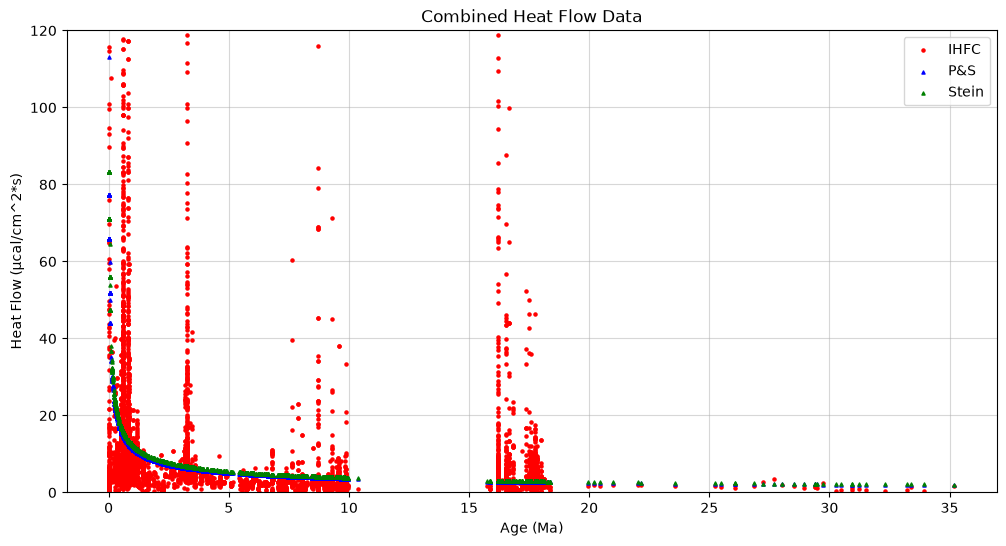

In [5]:
fig0, ax0 = plt.subplots(figsize=(12, 6))

ax0.scatter(df['age'], ihfc_qt, marker='o',color='red', s=5, label='IHFC')
ax0.scatter(df['age'], ps_qt, marker='^', color='blue', s=5, label='P&S')
ax0.scatter(df['age'], stein_qt, marker='^', color='green', s=5, label='Stein')
ax0.set_ylim(0, 120)
ax0.set_xlabel('Age (Ma)')
ax0.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax0.set_title('Combined Heat Flow Data')
ax0.set_axisbelow(True)

plt.grid(alpha=0.5)
plt.legend()
plt.show()

# tesseroid time!
Now we are going to plot the gravity as a tesseroid (6 bounds: west, east, south, north, bottom, top)

In [6]:
import boule as bl
import verde as vd
import harmonica as hm
from numba import njit

GRS80 (Geodetic Reference System 1980) vs WGS84 (World Geodetic System 1984) --> '...if you're using GPS coordinates or anything referenced to satellite positioning, you're technically in WGS84; if you're doing pure geodetic/gravity theory work, GRS80 is the traditional standard.'

In [7]:
ellipsoid = bl.WGS84
mean_radius = ellipsoid.mean_radius  # from boule, earth radius

### option 1: gygmt.surface: takes df['FA'] and fills in the gaps between using interpolation to smooth the og data or residuals.

[blockmedian](https://www.pygmt.org/latest/api/generated/pygmt.blockmedian.html#pygmt.blockmedian)

In [8]:
top = mean_radius - dt_ps  # places the top of the tesseroid at the predicted pars-scl seafloor depth
thickness = 7000  # assuming oceanic crust is 7km aka cmb
cmb = top - thickness
bottom = mean_radius - dt_ps - thickness  # places the bottom of the tesseroid at predicted pars-scl seafloor depth

region=df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max()
spacing=0.01  # number of pnts in each S-N and W-E direction, adjust based on data density

In [9]:
# block-reduce to avoid aliasing (average points within each grid cell)
block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=df['FA'],   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
grav_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

# print(grav_grid.head())

[make_xarray_grid](https://www.fatiando.org/verde/latest/api/generated/verde.make_xarray_grid.html#verde-make-xarray-grid)

projection --> 10c: width of the map (10 centimeters)

[fig.coast](https://www.pygmt.org/latest/api/generated/pygmt.Figure.coast.html)

cmap og range: -150 to 350

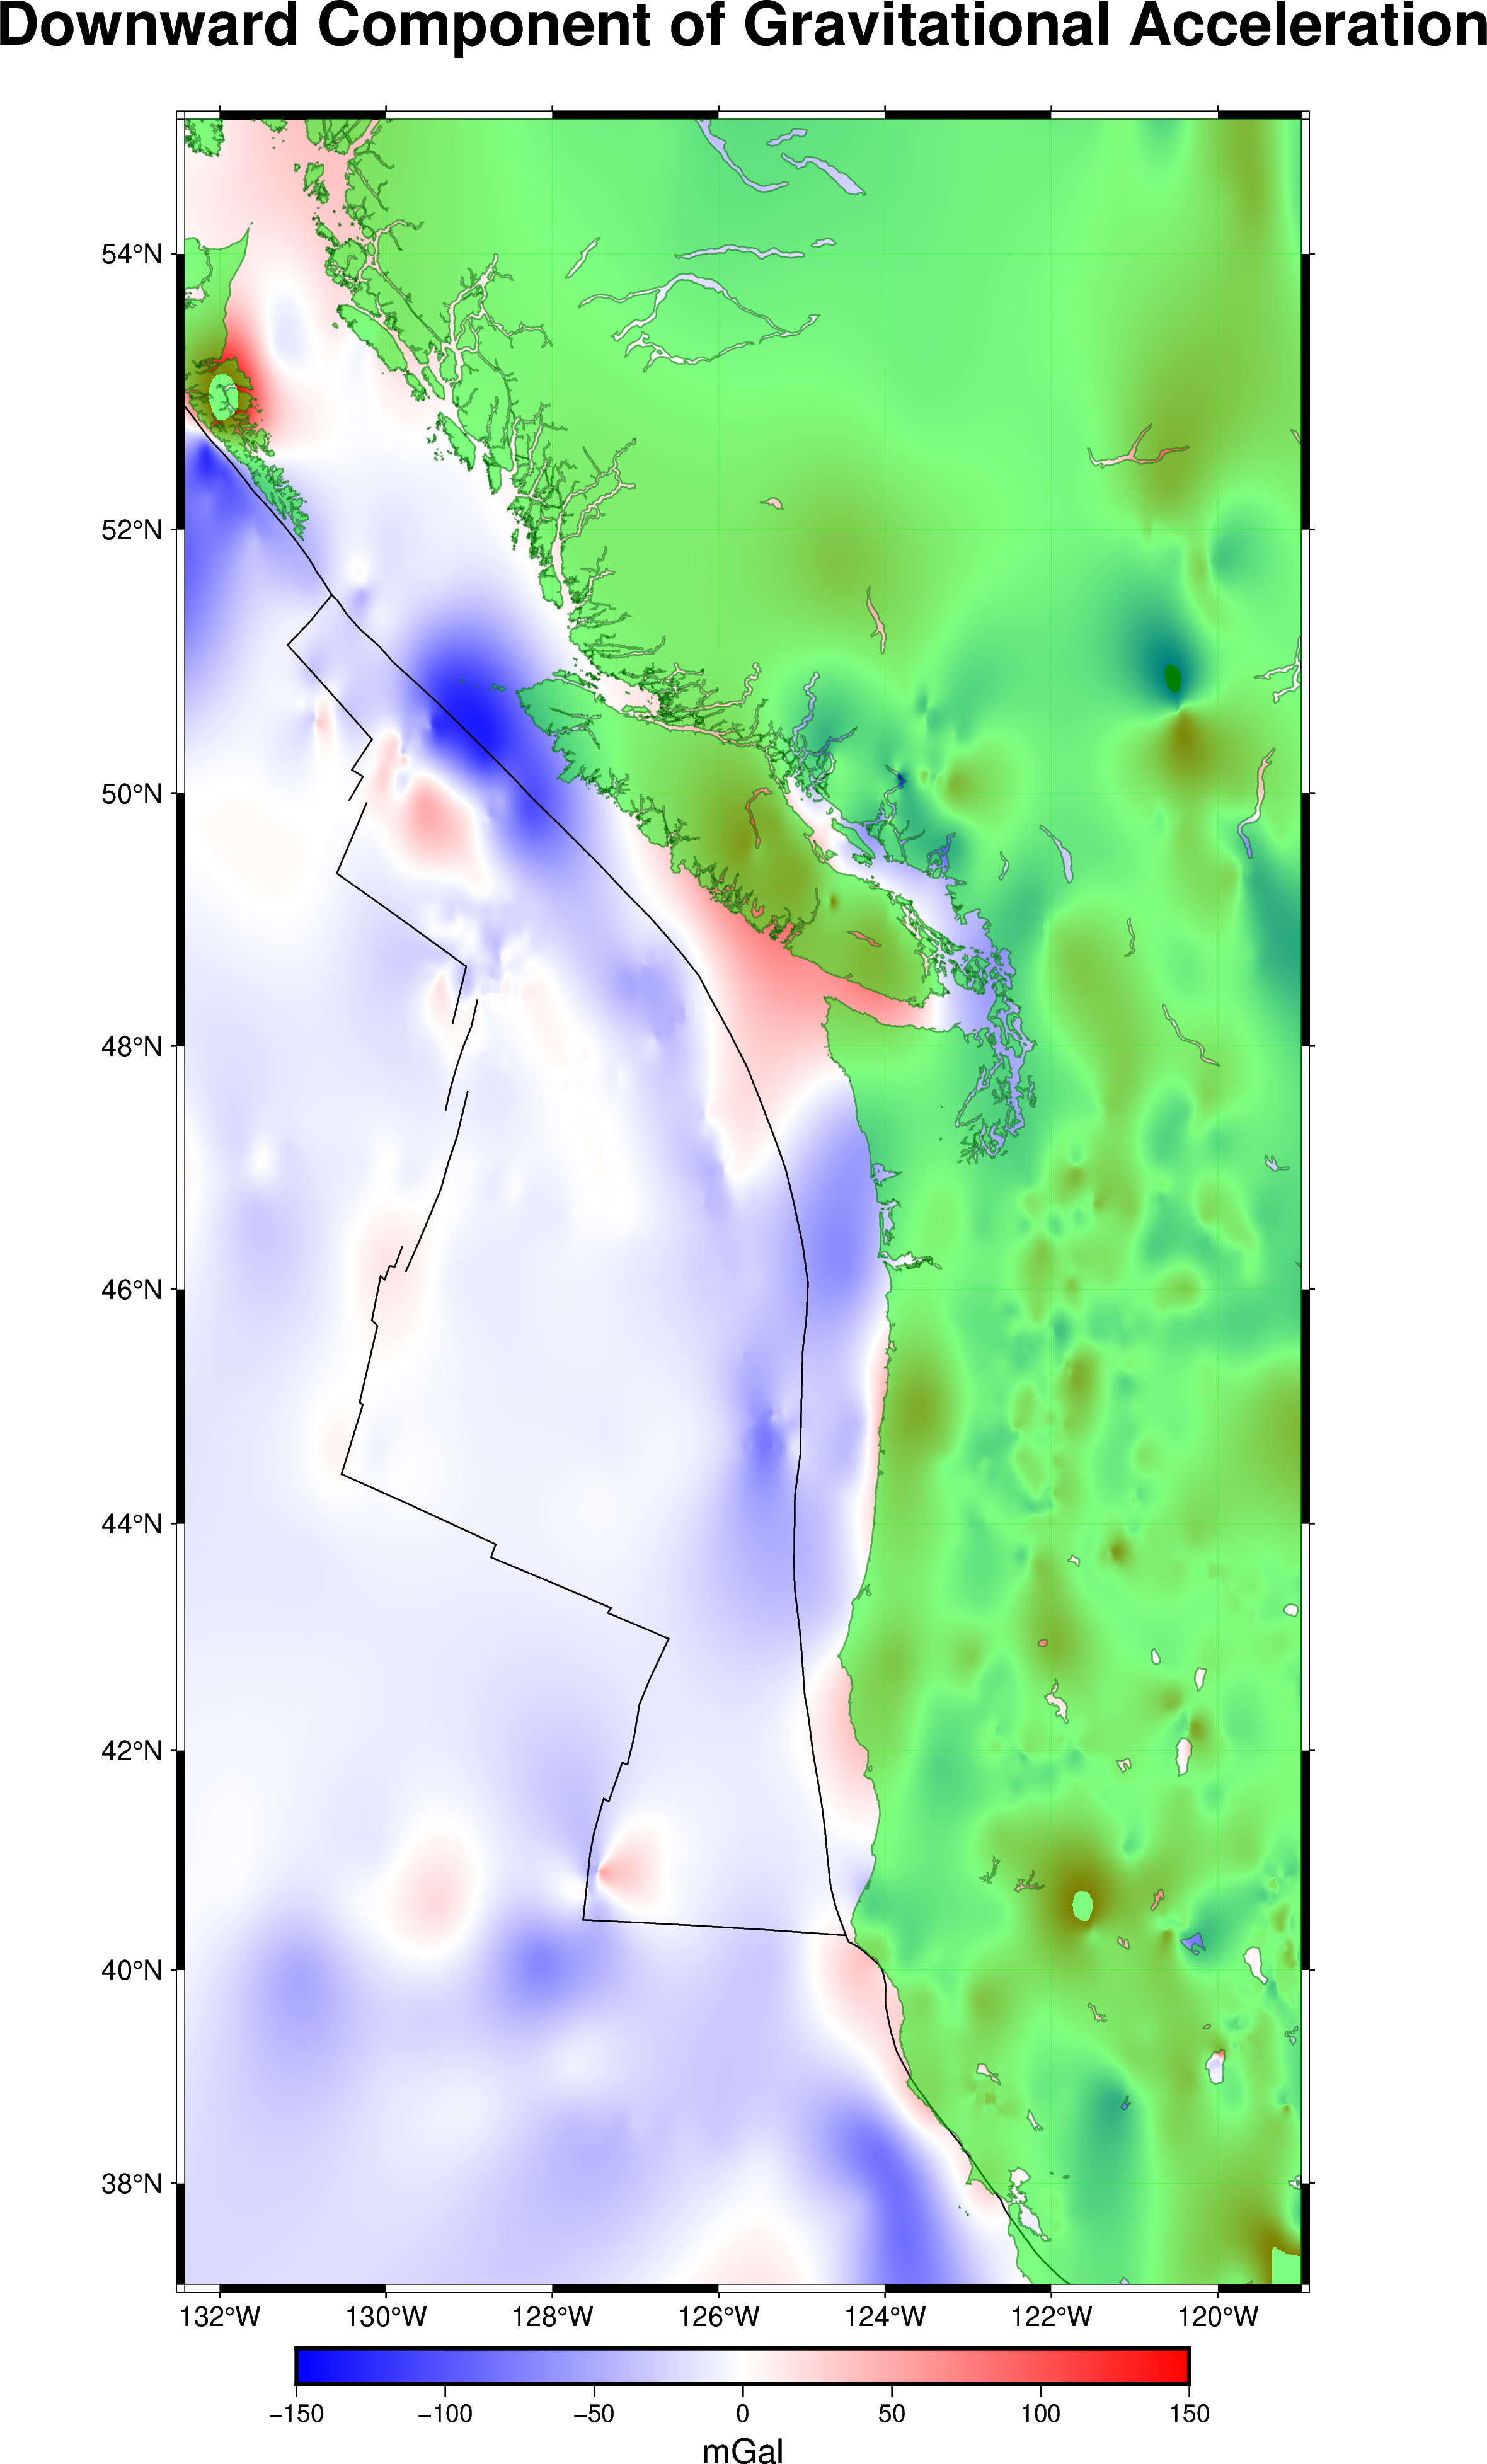

In [10]:
fig1 = pygmt.Figure()
title = 'Downward Component of Gravitational Acceleration'

pygmt.makecpt(cmap='polar', series=[-150, 150])  # sets the actual color range

fig1.grdimage(grid=grav_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig1.colorbar(cmap=True, frame=['a50f50', 'x+lmGal'])  # annotate every 50 mGal, tick every 50 mGal
fig1.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,black')
fig1.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')


fig1.savefig('..\\..\\figures\\jdf_grav\\grav_acc_0.01.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig1.show()

### option 2: hm.tesseroid_gravity: forward model that computes unknown gravity from a physical model

[vd.grid_coords](https://www.fatiando.org/verde/latest/api/generated/verde.grid_coordinates.html#verde-grid-coordinates) 

[hm.tesseroid_gravity](https://www.fatiando.org/harmonica/latest/api/generated/harmonica.tesseroid_gravity.html) --> from hm tesseroid example but takes too long for all the data

field options:
- grav potential: potential
- downward acc: g_z

extra_coords: adds a scalar constant array (such as a fixed height). can also make it a list for height, time, etc.

In [11]:
bottom = ellipsoid.mean_radius - 10e3
top = ellipsoid.mean_radius

print(df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max())

region=df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max()
spacing=0.01  # number of pnts in each S-N and W-E direction, adjust based on data density

-132.42 -119.0 37.03 54.94


In [12]:
@njit
def density(radius):
    """Linear density function"""
    top = mean_radius
    bottom = mean_radius - 10e3
    density_top = 2670
    density_bottom = 3000
    slope = (density_top - density_bottom) / (top - bottom)
    return slope * (radius - bottom) + density_bottom

In [13]:
# define the tesseroid as 6 parameters (hence 6 bounds meow)
tesseroid = ([df['lon'].min() + 5, df['lon'].max() - 4, df['lat'].min() + 4, df['lat'].max() - 6, 
                bottom, top],
            [df['lon'].min() + 4, df['lon'].max() - 3, df['lat'].min() + 5, df['lat'].max() - 3, 
                bottom, top],
            [df['lon'].min() + 2, df['lon'].max() - 6, df['lat'].min() + 1, df['lat'].max() - 10, 
                bottom, top])


# density = 3000  # [kg/m^3] for oceanic crust
# density = np.full(tesseroid.shape[0], density)

coords = vd.grid_coordinates(
    region=region,
    spacing=spacing,
    extra_coords=mean_radius)

gravity = hm.tesseroid_gravity(coords, tesseroid, density, field='g_z')

In [14]:
grid = vd.make_xarray_grid(coords, gravity, data_names='gravity', extra_coords_names='extra')

In [15]:
# df['gravity'] = gravity
# df['residual'] = df['FA'] - df['gravity']

# print(df['gravity'].head())
# print(df['residual'].head())

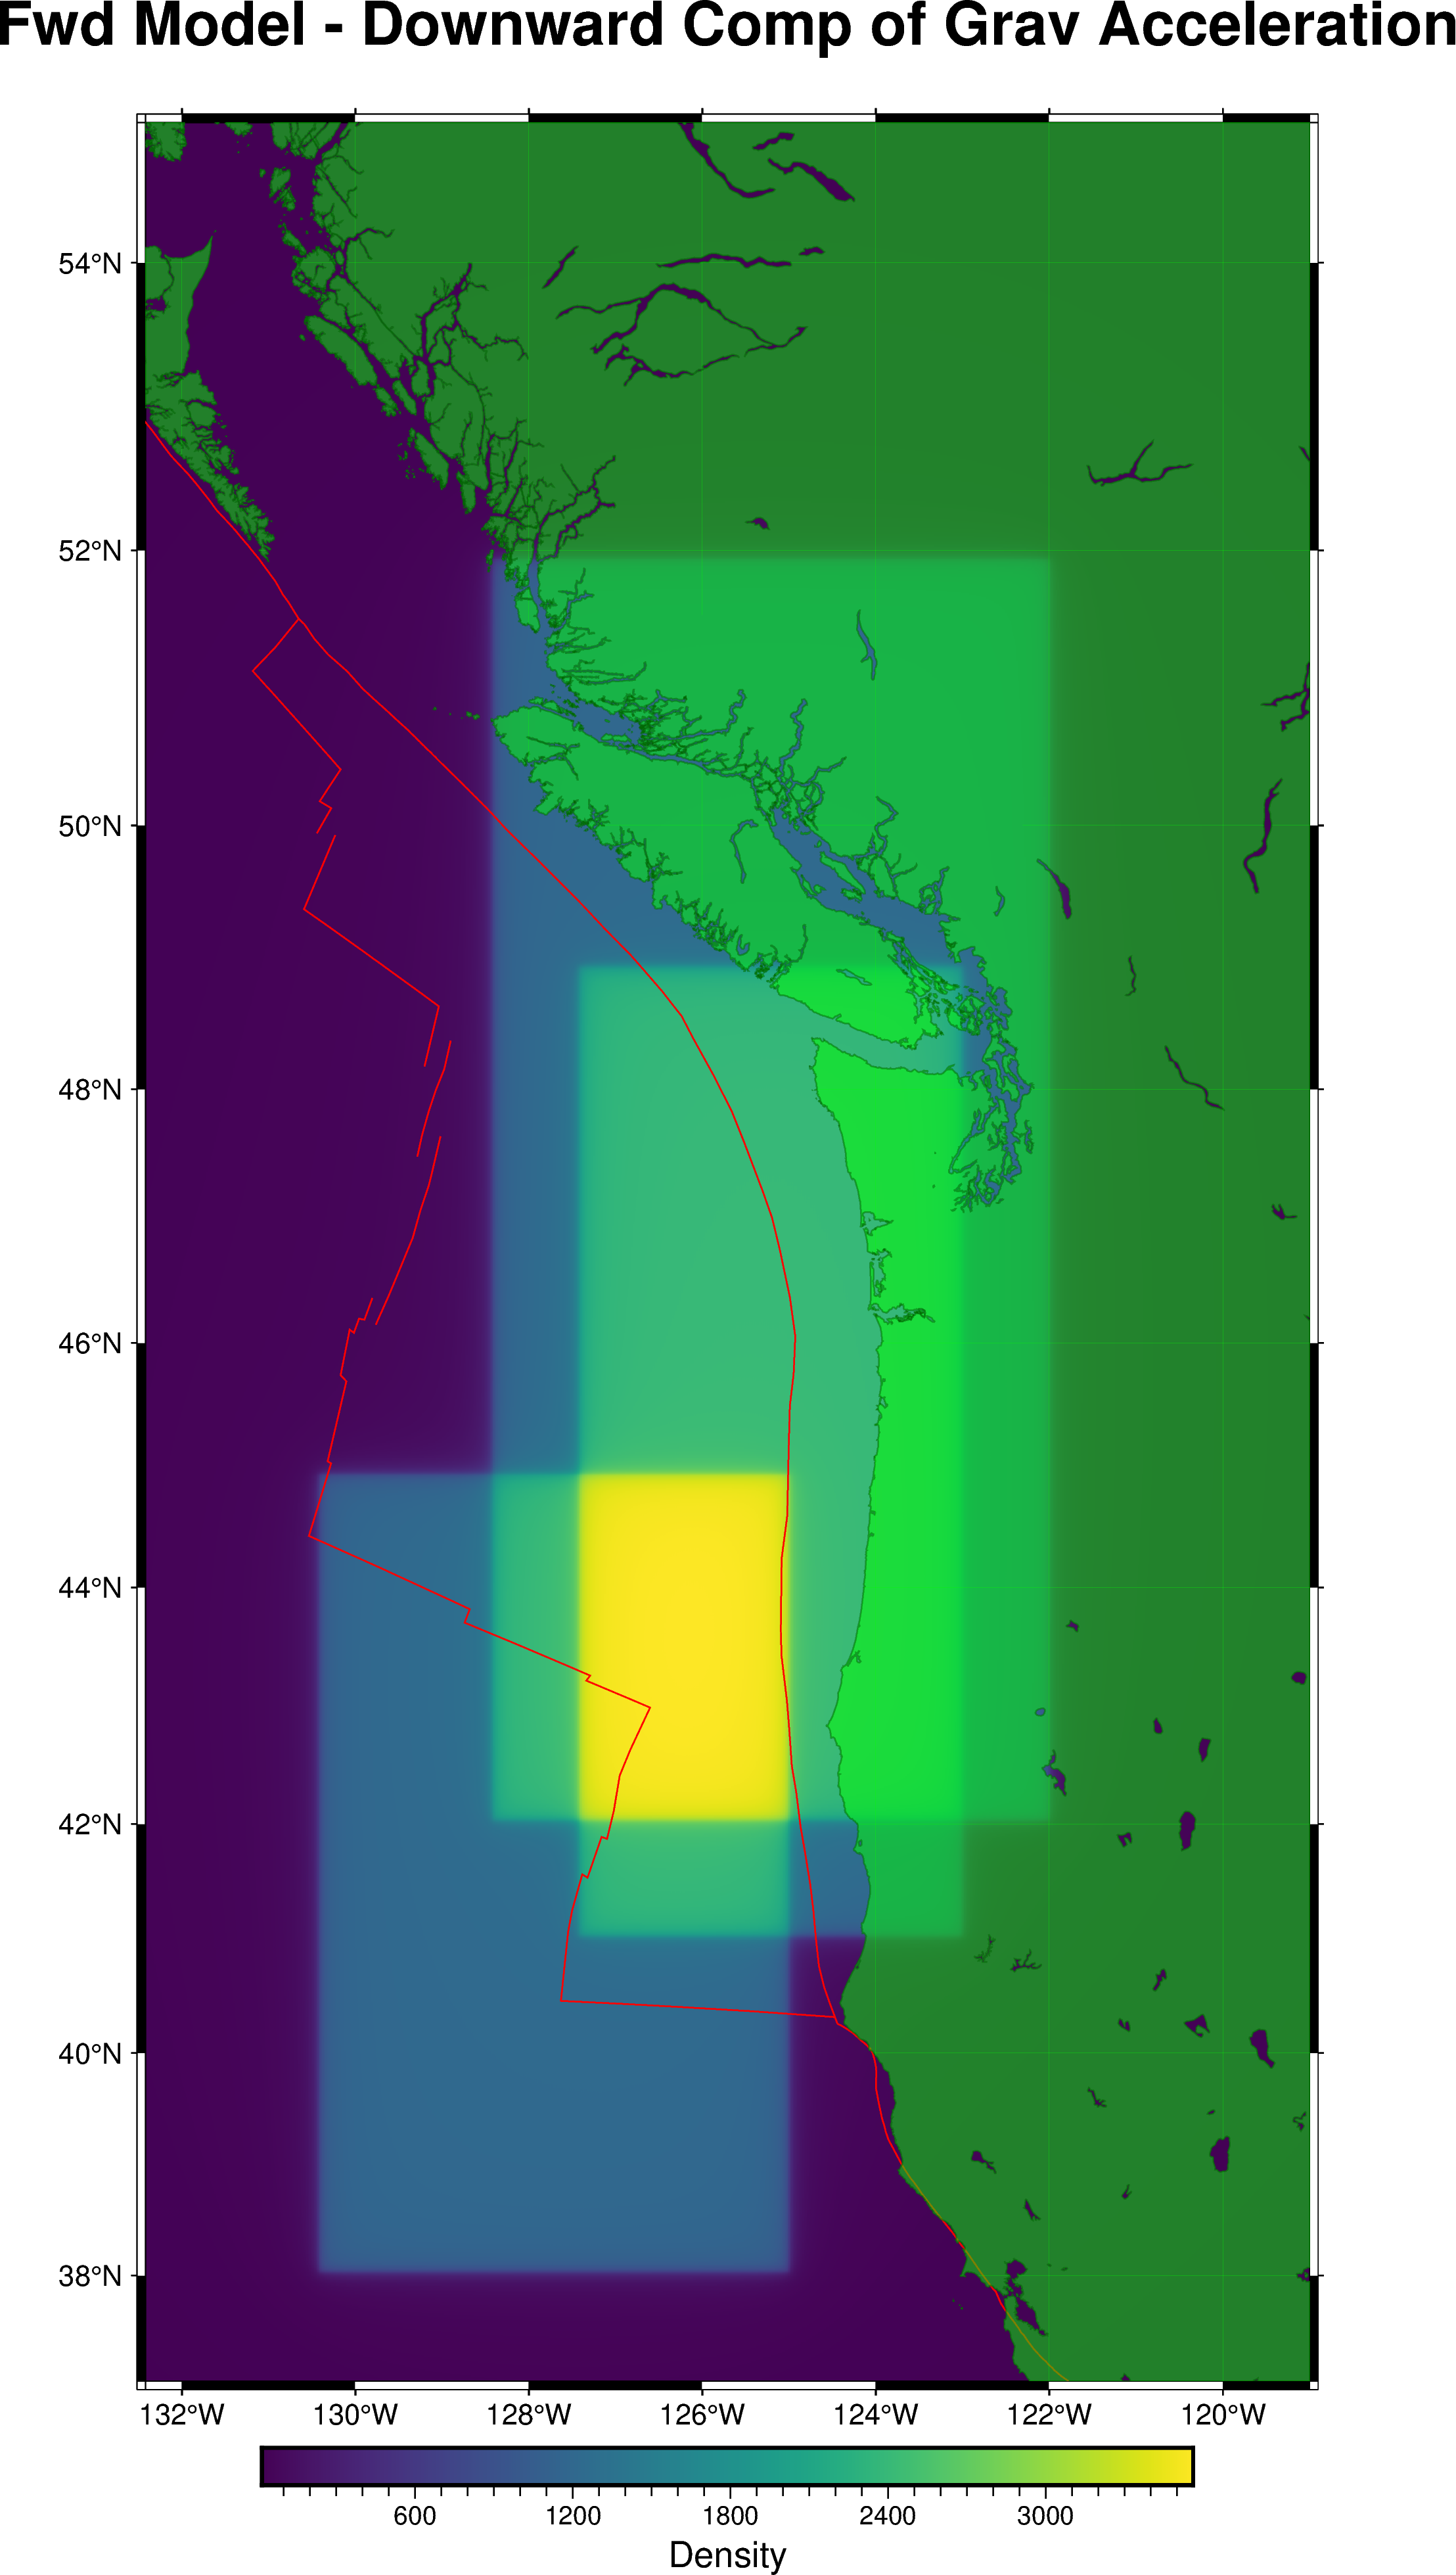

In [16]:
fig = pygmt.Figure()
title = 'Fwd Model - Downward Comp of Grav Acceleration'
with pygmt.config(FONT_TITLE='22p'):
   fig.grdimage(
      region=region,
      projection='M15c',
      grid=grid.gravity,
      frame=['a', f'+t{title}'],
      cmap='viridis',
   )

fig.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig.colorbar(cmap=True, frame=['a600f100', 'x+lDensity'])

fig.savefig('..\\..\\figures\\jdf_grav\\fwd_model_0.01.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig.show()

## making a depth tesseroid now...

In [17]:
block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=dt_ps,   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
ps_depth_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(ps_depth_grid.head())

block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=dt_stein,   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
stein_depth_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(stein_depth_grid.head())

<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[5245.4585, 5243.551 , 5241.6426, 5239.735 , 5237.8267],
       [5243.2974, 5241.397 , 5239.497 , 5237.5967, 5235.6963],
       [5241.136 , 5239.2437, 5237.351 , 5235.4585, 5233.566 ],
       [5238.975 , 5237.0903, 5235.2056, 5233.3203, 5231.4355],
       [5236.814 , 5234.9365, 5233.0596, 5231.1826, 5229.305 ]],
      dtype=float32)
Coordinates:
  * y        (y) float64 40B 37.03 37.04 37.05 37.06 37.07
  * x        (x) float64 40B -132.4 -132.4 -132.4 -132.4 -132.4
Attributes:
    Conventions:   CF-1.7
    title:         Data gridded with continuous surface splines in tension
    history:       gmt surface @GMTAPI@-S-I-D-V-T-N-000000 -G@GMTAPI@-S-O-G-G...
    description:   
    actual_range:  [nan nan]
    long_name:     z
<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[5463.1206, 5461.131 , 5459.141 , 5457.1514, 5455.1616],
       [5460.8667, 5458.8853, 5456.9033, 5454.922 , 5452.94  ],
       [5458.6133, 5456.6396, 5454.6

makecpt error: if you don't set the series it may not show the data

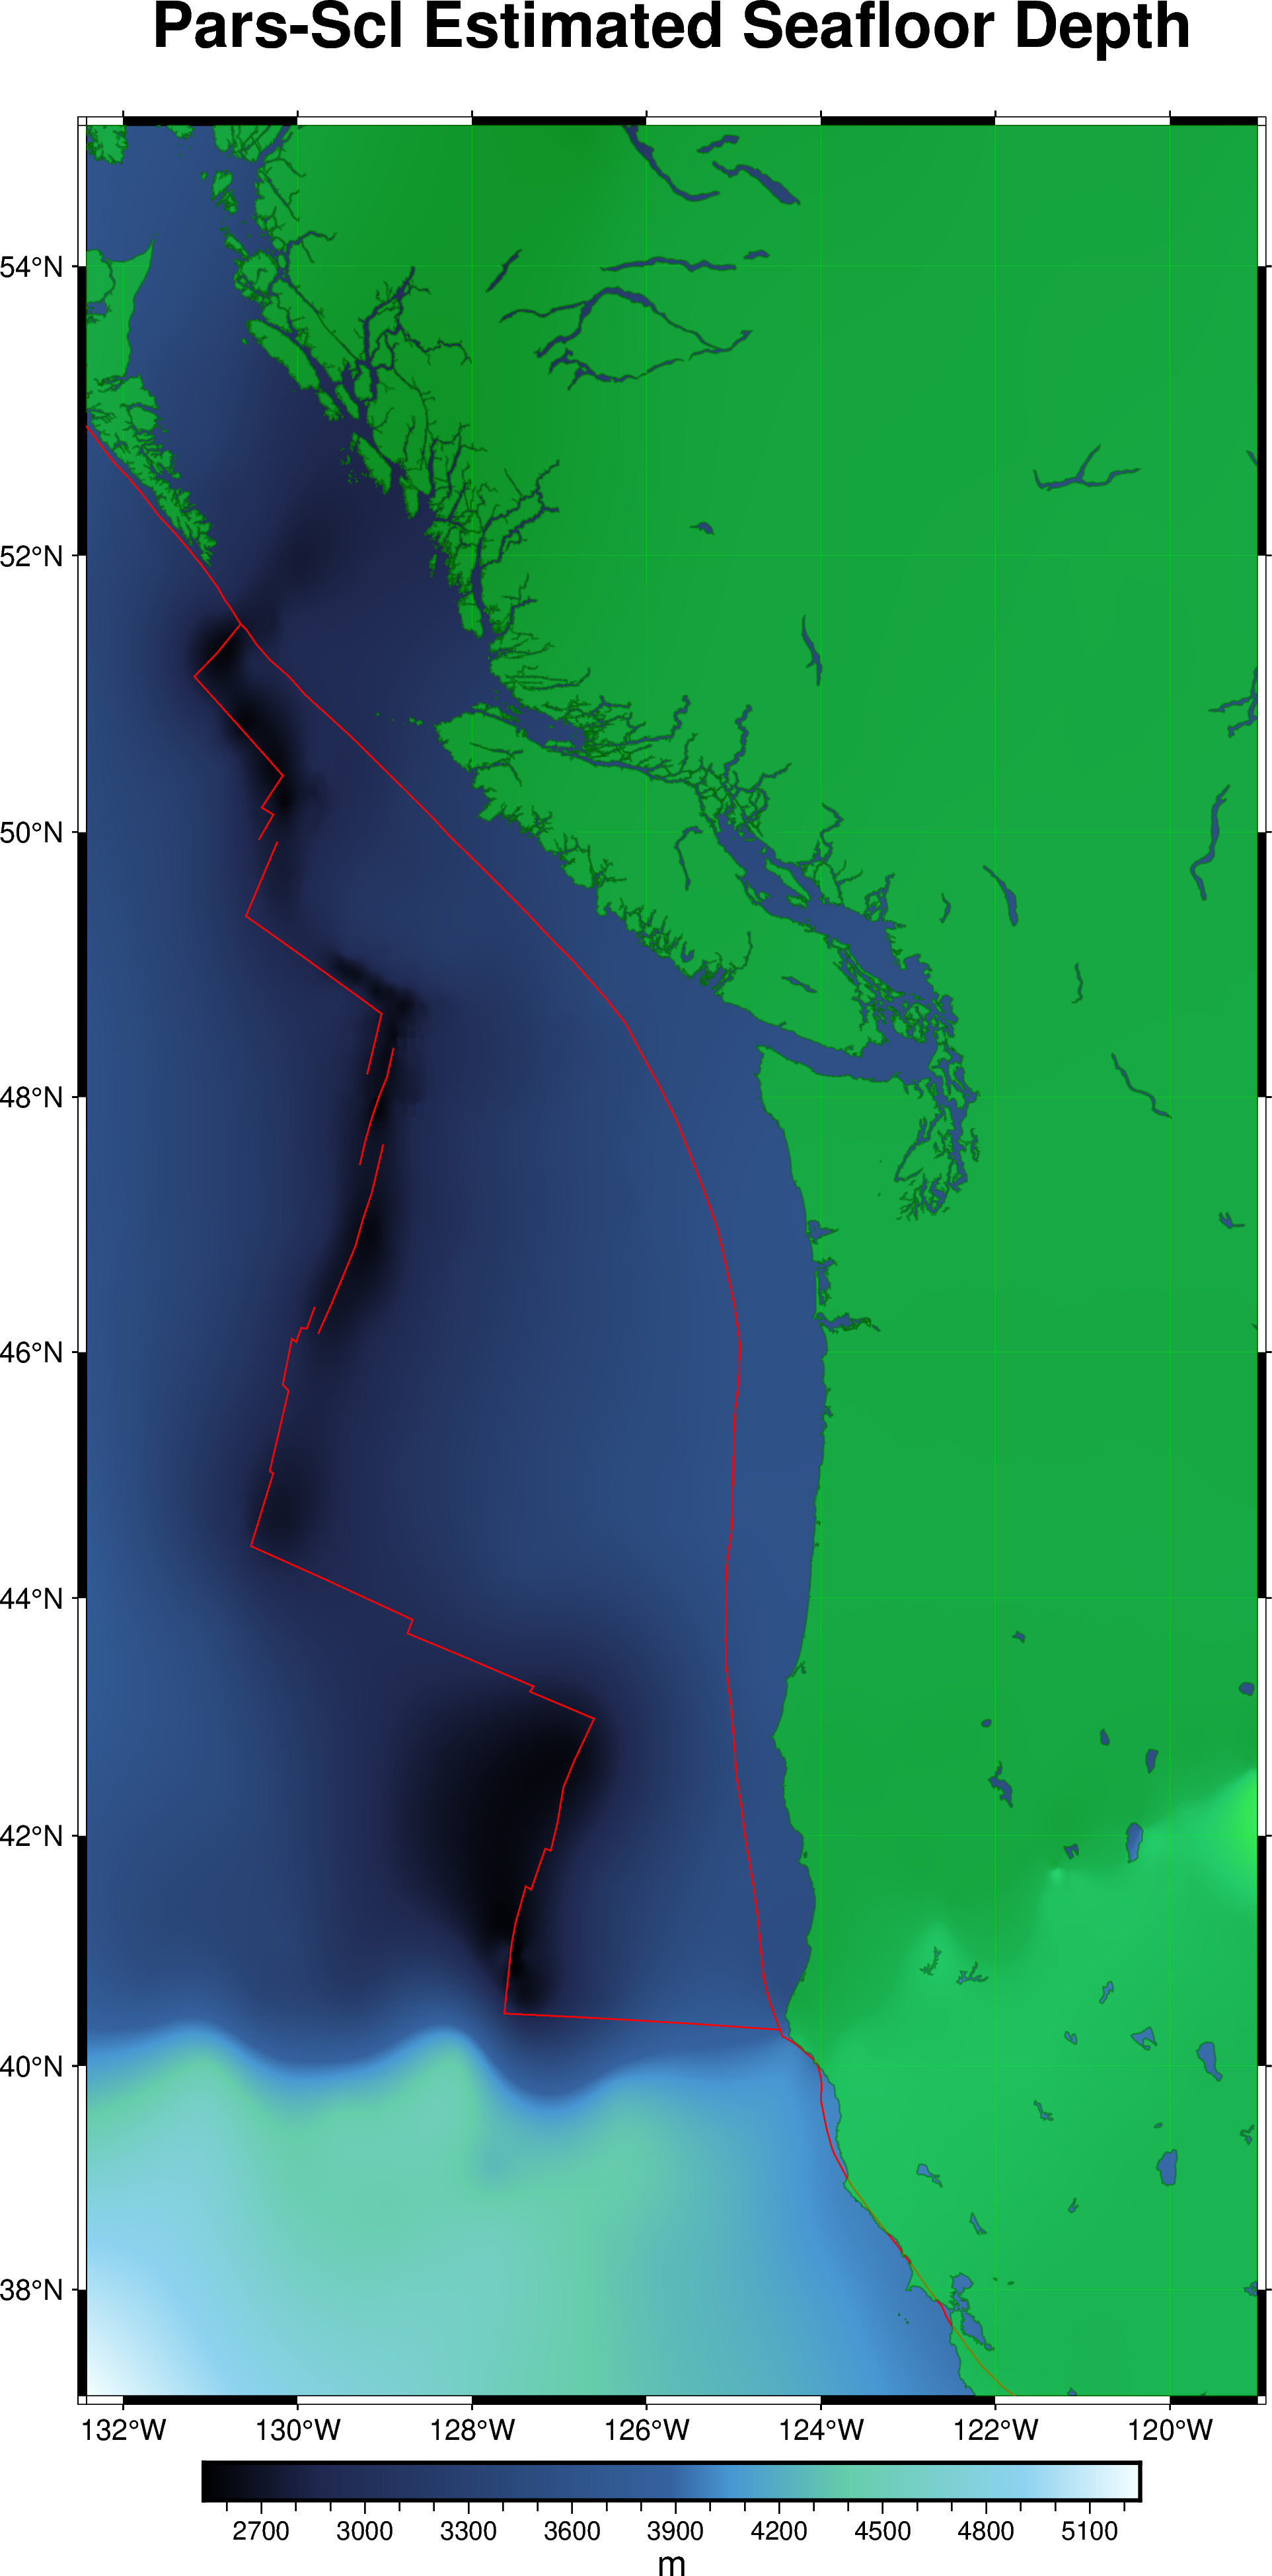

In [18]:
fig2 = pygmt.Figure()
title = 'Pars-Scl Estimated Seafloor Depth'

pygmt.makecpt(cmap='bathy', series=[ps_depth_grid.min().values, ps_depth_grid.max().values])

fig2.grdimage(grid=ps_depth_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig2.colorbar(cmap=True, frame=['a300f100', 'x+lm'])  # annotate every x, tick every y
fig2.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig2.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig2.savefig('..\\..\\figures\\jdf_grav\\depth_ps_0.01.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig2.show()

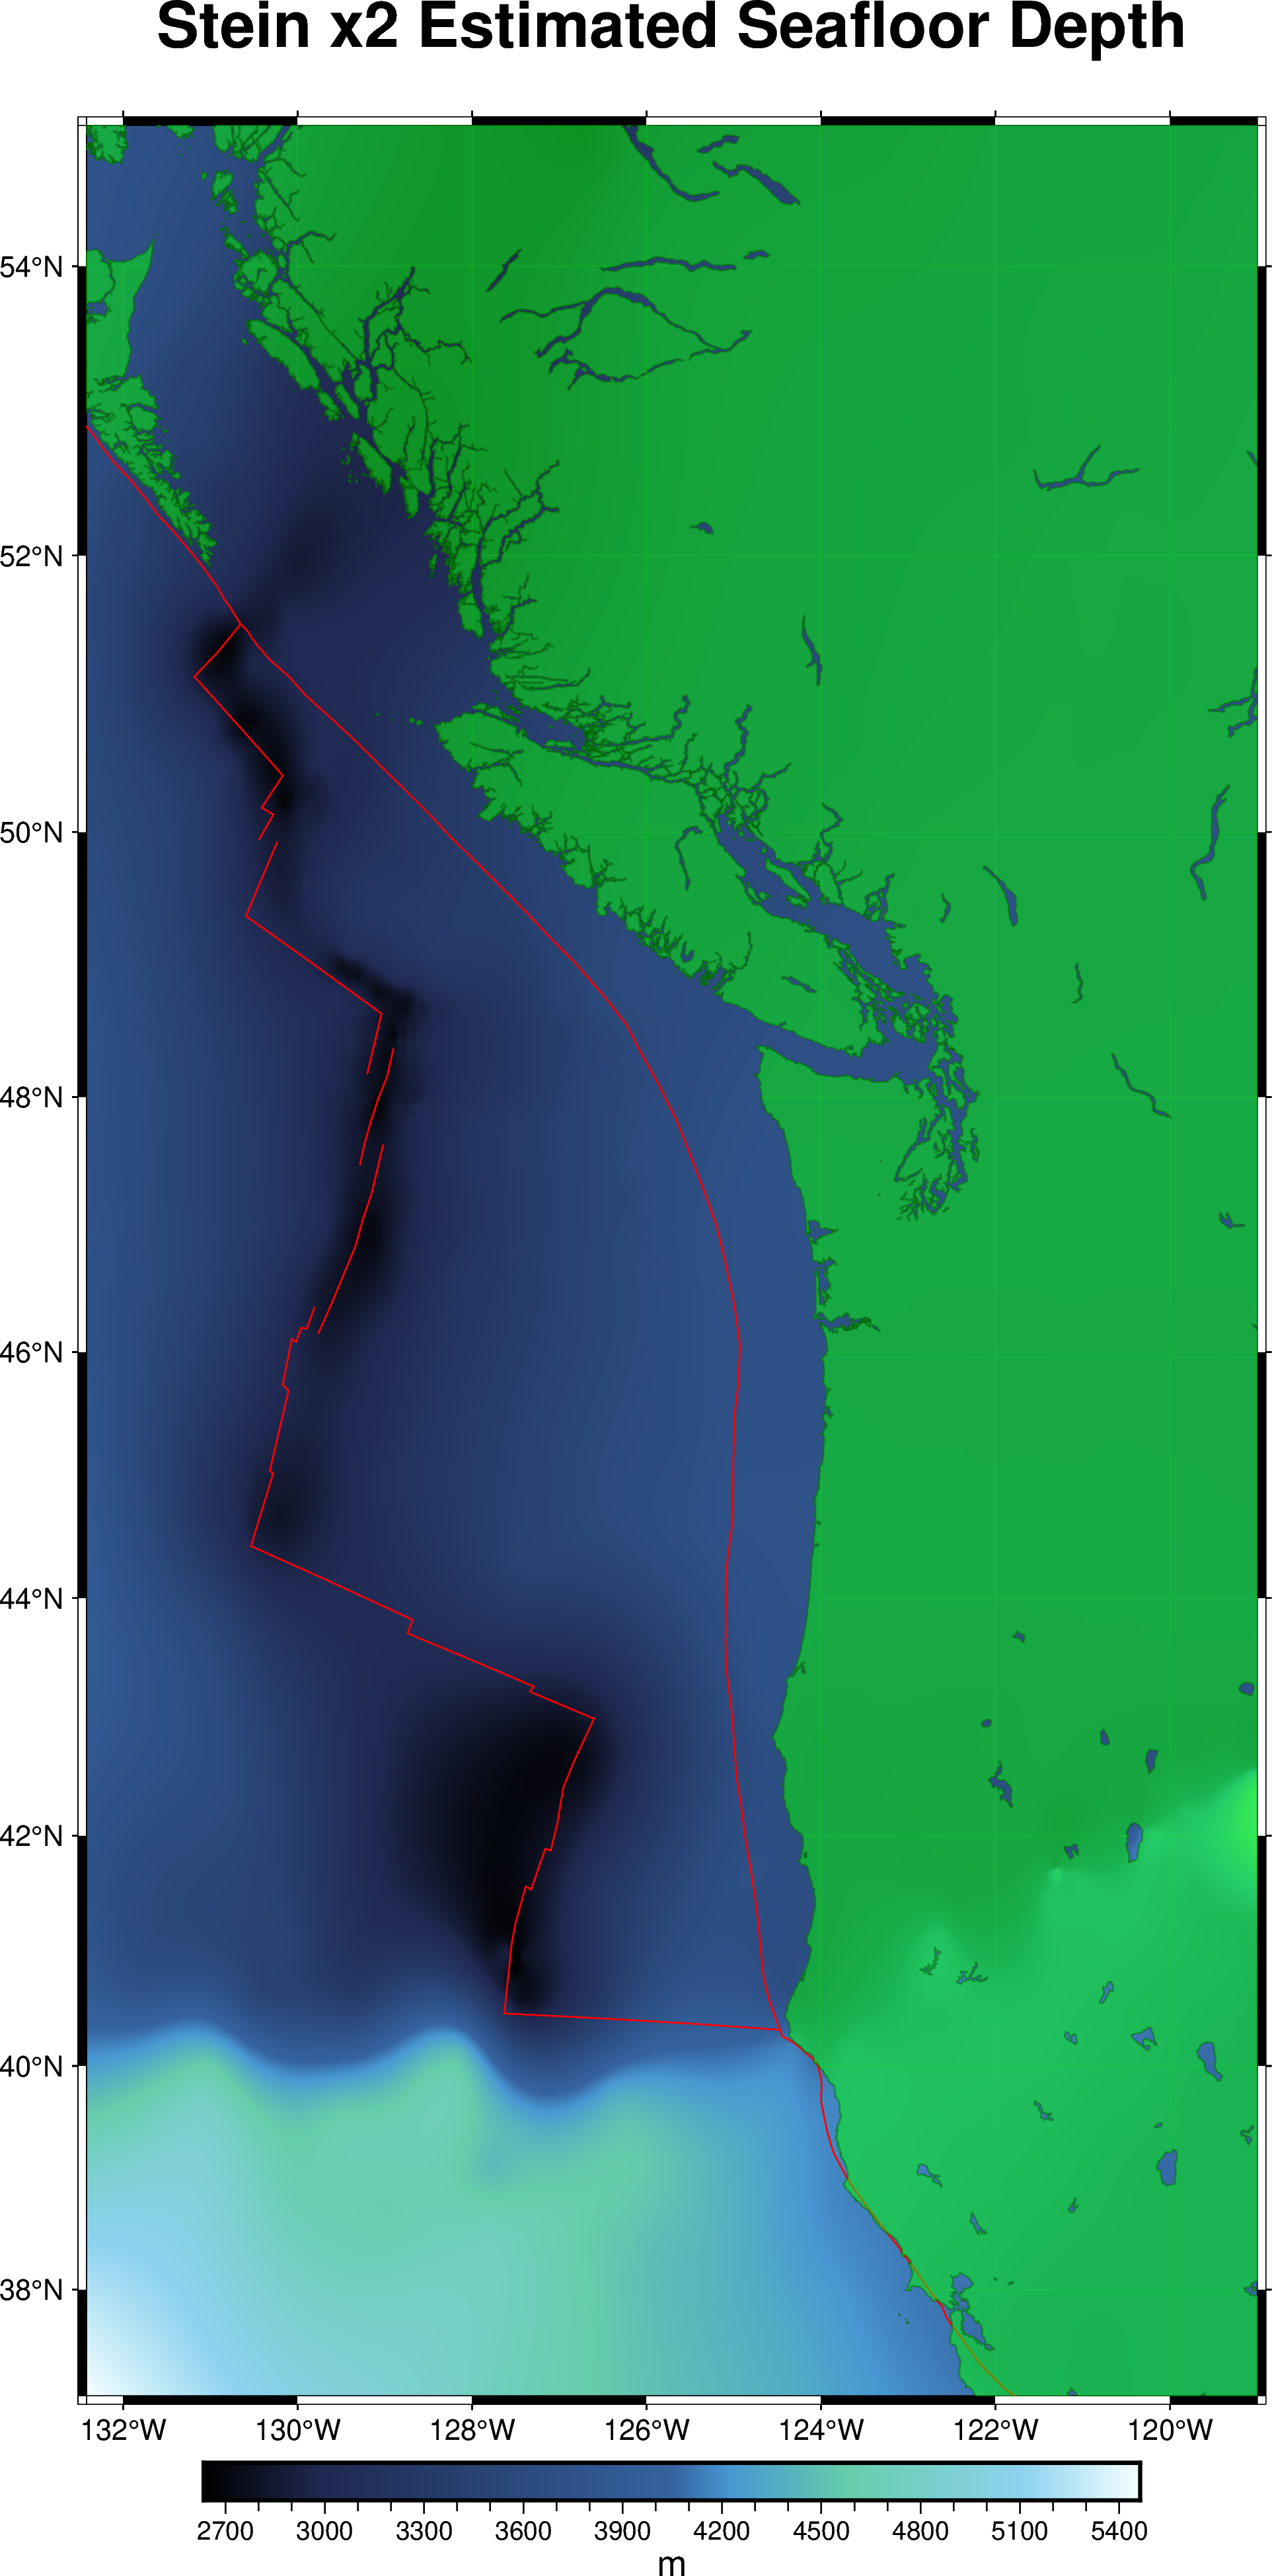

In [19]:
fig3 = pygmt.Figure()
title = 'Stein x2 Estimated Seafloor Depth'

pygmt.makecpt(cmap='bathy', series=[stein_depth_grid.min().values, stein_depth_grid.max().values])

fig3.grdimage(grid=stein_depth_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig3.colorbar(cmap=True, frame=['a300f100', 'x+lm'])  # annotate every x, tick every y
fig3.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig3.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig3.savefig('..\\..\\figures\\jdf_grav\\depth_stein_0.01.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig3.show()

In [20]:
diff_depth = stein_depth_grid - ps_depth_grid

# print(diff_depth.head())

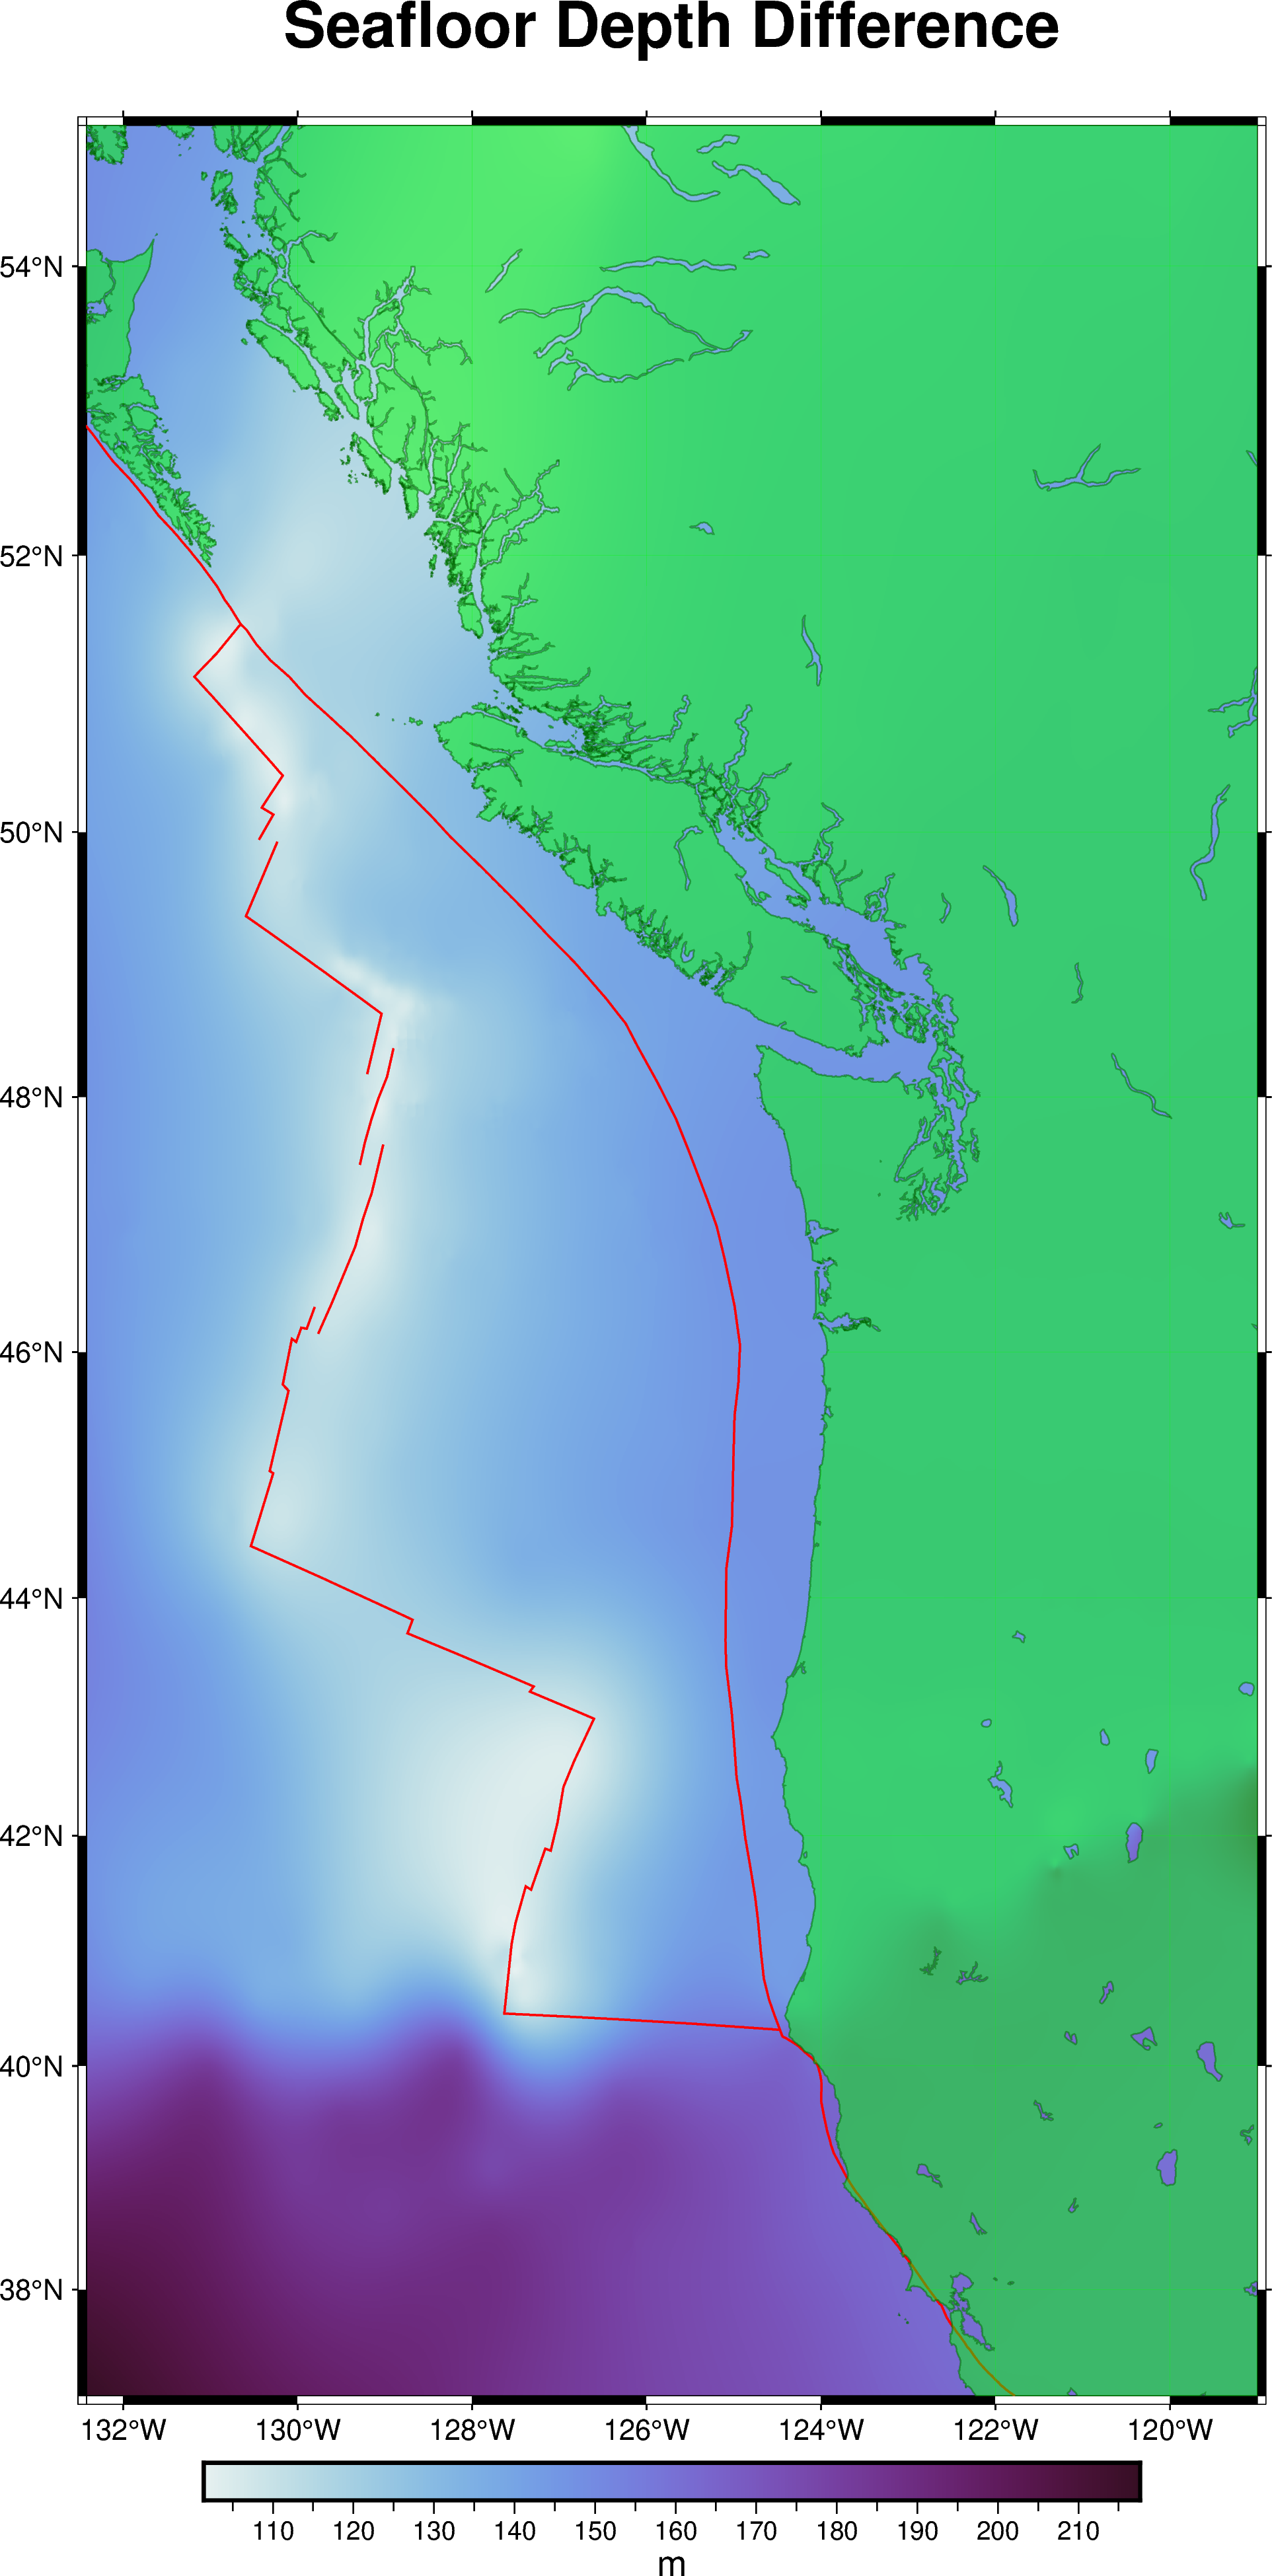

In [21]:
fig4 = pygmt.Figure()
title = 'Seafloor Depth Difference'

pygmt.makecpt(cmap='dense', series=[diff_depth.min().values, diff_depth.max().values])

fig4.grdimage(grid=diff_depth, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig4.colorbar(cmap=True, frame=['a10f5', 'x+lm'])  # annotate every x, tick every y
fig4.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.75p,red')
fig4.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig4.savefig('..\\..\\figures\\jdf_grav\\depth_diff_0.01.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig4.show()

## plotting gebco data

In [ ]:
fig5 = pygmt.Figure()
title = 'Seabed Data'

pygmt.makecpt(cmap='abyss', series=[-5000, 1000])

fig5.grdimage(grid='..\\..\\data\\GEBCO_20_Jul_2026_602a71007e75\\seabed.grd', cmap=True, 
              region=region, projection='M15c', 
              frame=['xa2f2g1','ya2f2g1', f'+t{title}'] # annot every 2, 2 ticks inbwtn, 1 gridline
              )
fig5.colorbar(cmap=True, frame=['a1000f500', 'x+lm'])  # annotate every x, tick every y
fig5.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='1p,red')
fig5.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig5.savefig('..\\..\\figures\\jdf_grav\\seabed_grded_0.01.png', dpi=500, crop='0.5c')  # crop to put whitespace around when i save it
fig5.show()